In [1]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [2]:
import pandas as pd
df = pd.read_excel("부산_구군별_연도별_방문자수_2021_2025_final.xlsx")

In [3]:
df["외지/외국인"] = df["외지인"] + df["외국인"]

In [4]:
df2 = pd.read_excel("내외국인 총관광소비 데이터.xlsx")

In [5]:
df2

,기준년월,지자체,카테고리,소비금액(천원),Unnamed: 4,Unnamed: 5,카테고리.1,항목
0,2021,강서구,숙박,4002957,NaN,NaN,숙박,"호텔, 캠핑장/펜션, 기타숙박"
1,2021,강서구,쇼핑,126733169,NaN,NaN,쇼핑,"면세점, 기타관광쇼핑, 레저용품소핑, 대형쇼핑몰, 뷰티"
2,2021,강서구,레저·문화,8844215,NaN,NaN,레저·문화,"골프장, 기타레저, 문화서비스"
3,2021,강서구,외식,81357550,NaN,NaN,외식,"일반외식업, 제과음료업"
4,2021,강서구,교통·여행,307097382,NaN,NaN,교통·여행,"여행업, 육상운송, 수상운송, 렌터카"
...,...,...,...,...,...,...,...,...
395,2025,해운대구,숙박,106415759,NaN,NaN,NaN,NaN
396,2025,해운대구,쇼핑,1737311883,NaN,NaN,NaN,NaN
397,2025,해운대구,레저·문화,23242826,NaN,NaN,NaN,NaN
398,2025,해운대구,외식,375427107,NaN,NaN,NaN,NaN


In [6]:
extract_df = df2.groupby(["기준년월","지자체"]).sum("소비금액(천원)").iloc[:,:1].reset_index()

In [7]:
extract_df

,기준년월,지자체,소비금액(천원)
0,2021,강서구,528035273
1,2021,금정구,268953900
2,2021,기장군,815770607
3,2021,남구,328692447
4,2021,동구,256884076
...,...,...,...
75,2025,수영구,450459813
76,2025,연제구,447451141
77,2025,영도구,98926213
78,2025,중구,419215269


In [8]:
df[["연도","구군","외지/외국인"]]

,연도,구군,외지/외국인
0,2021,강서구,32525575.91
1,2022,강서구,37258303.17
2,2023,강서구,42675733.09
3,2024,강서구,45097425.58
4,2025,강서구,50128293.43
...,...,...,...
75,2021,해운대구,60267611.49
76,2022,해운대구,66757960.34
77,2023,해운대구,69607864.21
78,2024,해운대구,71339735.79


In [11]:
# 첫 번째 데이터 컬럼명 통일
extract_df = extract_df.rename(columns={
    '기준년월': '연도',
    '지자체': '구군',
    '소비금액(천원)': '소비금액'
})

# 병합
merged_df = pd.merge(
    extract_df,
    df[['연도', '구군', '외지/외국인']],
    on=['연도', '구군'],
    how='left'
)

merged_df

,연도,구군,소비금액,외지/외국인
0,2021,강서구,528035273,32525575.91
1,2021,금정구,268953900,25903801.27
2,2021,기장군,815770607,37806926.51
3,2021,남구,328692447,26669924.21
4,2021,동구,256884076,24949339.64
...,...,...,...,...
75,2025,수영구,450459813,42992660.20
76,2025,연제구,447451141,33047253.42
77,2025,영도구,98926213,20996440.05
78,2025,중구,419215269,43540455.43


In [12]:
merged_df.isna().sum()

연도        0
구군        0
소비금액      0
외지/외국인    0
dtype: int64

In [16]:
merged_df2 = merged_df[merged_df["연도"]==2025].reset_index(drop=True)

In [21]:
merged_df2.groupby("구군")[['소비금액', '외지/외국인']].sum()

,소비금액,외지/외국인
구군,,
강서구,845860431,50128293.43
금정구,307413873,31398339.66
기장군,1003037901,43965450.46
남구,395013294,34463666.57
동구,367088179,41498883.23
동래구,503734111,42955565.48
부산진구,1021133917,78991682.30
북구,1085892953,25657060.92
사상구,425710805,30243456.03


In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


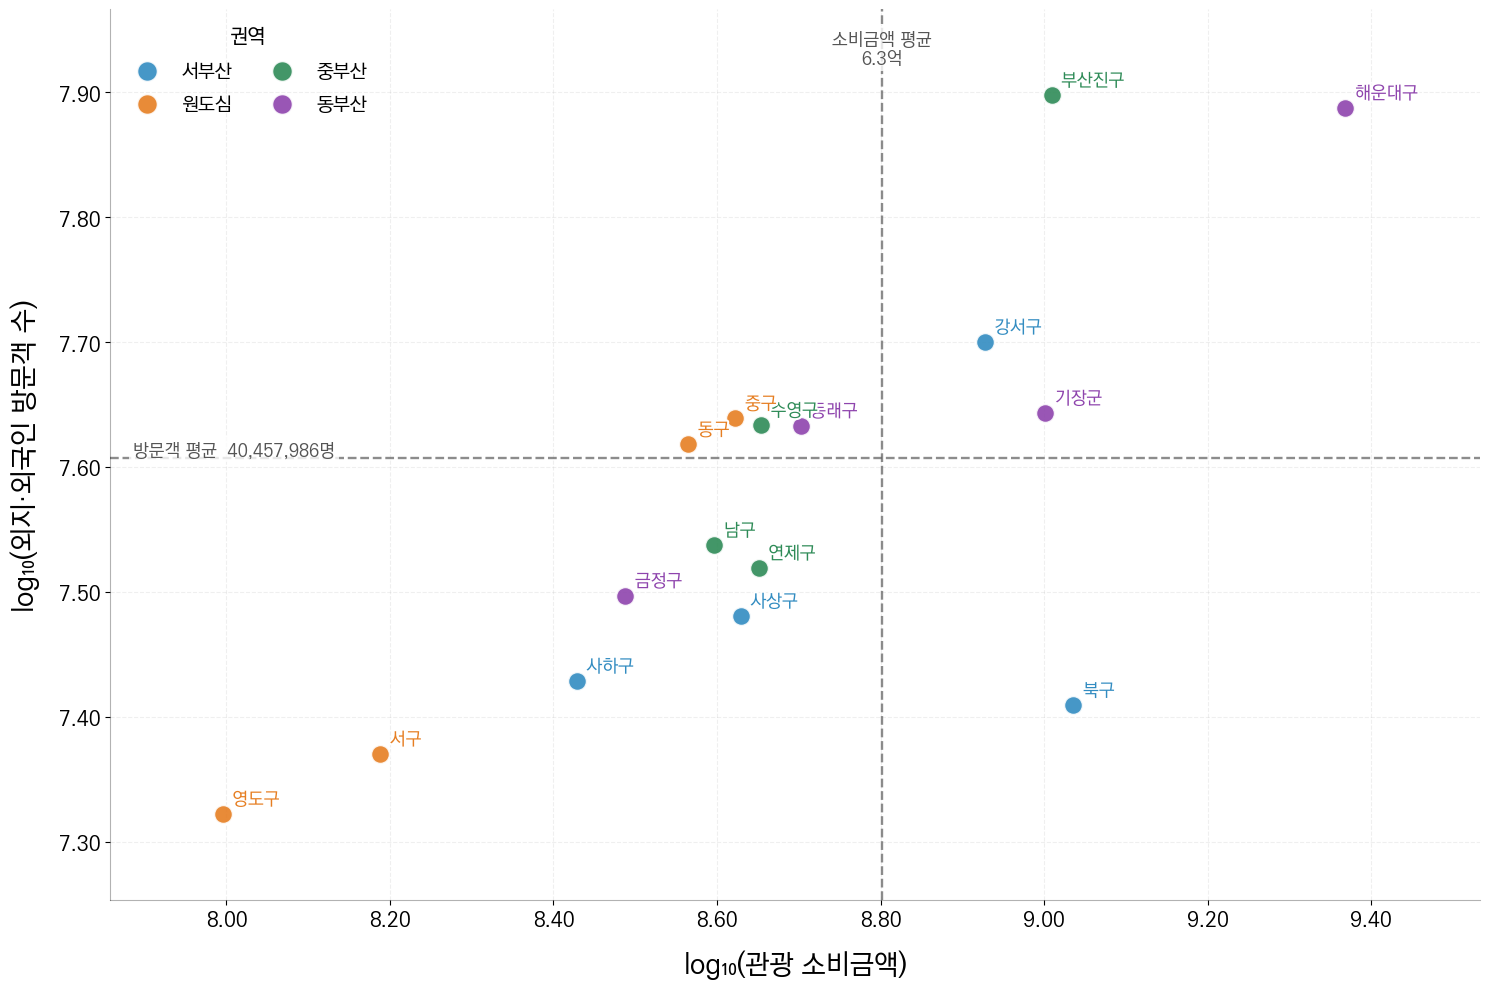

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch


# =========================================================
# 1. 구군별 합계
# =========================================================

scatter_df = (
    merged_df2
    .groupby(
        "구군",
        as_index=False
    )[
        ["소비금액", "외지/외국인"]
    ]
    .sum()
)


# =========================================================
# 2. 부산 4개 권역
# =========================================================

region_map = {
    # 원도심
    "중구": "원도심",
    "동구": "원도심",
    "서구": "원도심",
    "영도구": "원도심",

    # 중부산
    "남구": "중부산",
    "부산진구": "중부산",
    "수영구": "중부산",
    "연제구": "중부산",

    # 서부산
    "강서구": "서부산",
    "북구": "서부산",
    "사상구": "서부산",
    "사하구": "서부산",

    # 동부산
    "금정구": "동부산",
    "기장군": "동부산",
    "동래구": "동부산",
    "해운대구": "동부산",
}


scatter_df["권역"] = (
    scatter_df["구군"]
    .map(region_map)
)


# =========================================================
# 3. 권역별 색상
# =========================================================

region_colors = {
    "서부산": "#328CC1",
    "원도심": "#E67E22",
    "중부산": "#2E8B57",
    "동부산": "#8E44AD"
}

region_order = [
    "서부산",
    "원도심",
    "중부산",
    "동부산"
]


# =========================================================
# 4. log10 변환
# =========================================================

scatter_df["소비금액_log"] = np.log10(
    scatter_df["소비금액"]
)

scatter_df["방문객_log"] = np.log10(
    scatter_df["외지/외국인"]
)


# =========================================================
# 5. 실제 값 기준 산술평균
# =========================================================

x_mean_raw = scatter_df["소비금액"].mean()

y_mean_raw = scatter_df["외지/외국인"].mean()


# =========================================================
# 6. 평균값을 log10 좌표로 변환
# =========================================================

x_mean_log = np.log10(
    x_mean_raw
)

y_mean_log = np.log10(
    y_mean_raw
)


# =========================================================
# 7. 그래프
# =========================================================

fig, ax = plt.subplots(
    figsize=(15, 10)
)


# =========================================================
# 8. 권역별 산점도
# =========================================================

for region in region_order:

    temp = scatter_df[
        scatter_df["권역"] == region
    ]

    ax.scatter(
        temp["소비금액_log"],
        temp["방문객_log"],

        s=180,

        color=region_colors[region],

        edgecolor="white",
        linewidth=1.5,

        alpha=0.90,

        label=region,

        zorder=5
    )


# =========================================================
# 9. 구군 레이블
# =========================================================

text_effect = [
    pe.Stroke(
        linewidth=3,
        foreground="white"
    ),
    pe.Normal()
]


for _, row in scatter_df.iterrows():

    ax.annotate(
        row["구군"],

        xy=(
            row["소비금액_log"],
            row["방문객_log"]
        ),

        xytext=(7, 7),

        textcoords="offset points",

        fontsize=13,
        fontweight="bold",

        color=region_colors[row["권역"]],

        path_effects=text_effect,

        zorder=10
    )


# =========================================================
# 10. 소비금액 평균선
# =========================================================

ax.axvline(
    x=x_mean_log,

    color="#666666",

    linestyle="--",
    linewidth=1.7,

    alpha=0.75,

    zorder=1
)


# =========================================================
# 11. 방문객 평균선
# =========================================================

ax.axhline(
    y=y_mean_log,

    color="#666666",

    linestyle="--",
    linewidth=1.7,

    alpha=0.75,

    zorder=1
)


# =========================================================
# 12. 축 범위 계산
# =========================================================

x_min = scatter_df["소비금액_log"].min()
x_max = scatter_df["소비금액_log"].max()

y_min = scatter_df["방문객_log"].min()
y_max = scatter_df["방문객_log"].max()

x_range = x_max - x_min
y_range = y_max - y_min


ax.set_xlim(
    x_min - x_range * 0.10,
    x_max + x_range * 0.12
)

ax.set_ylim(
    y_min - y_range * 0.12,
    y_max + y_range * 0.12
)


# =========================================================
# 13. 평균선 레이블
# =========================================================

# 세로 평균선 레이블
ax.text(
    x_mean_log,
    ax.get_ylim()[1] - y_range * 0.03,

    f"소비금액 평균\n{x_mean_raw / 100_000_000:,.1f}억",

    ha="center",
    va="top",

    fontsize=13,
    fontweight="bold",

    color="#555555",

    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.80,
        pad=3
    ),

    zorder=20
)


# 가로 평균선 레이블
ax.text(
    ax.get_xlim()[0] + x_range * 0.02,
    y_mean_log,

    f"방문객 평균  {y_mean_raw:,.0f}명",

    ha="left",
    va="bottom",

    fontsize=13,
    fontweight="bold",

    color="#555555",

    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.80,
        pad=3
    ),

    zorder=20
)


# =========================================================
# X축
# =========================================================

ax.set_xlabel(
    'log₁₀(관광 소비금액)',
    fontsize=20,
    fontweight='bold',
    labelpad=14
)


# =========================================================
# Y축
# =========================================================

ax.set_ylabel(
    'log₁₀(외지·외국인 방문객 수)',
    fontsize=20,
    fontweight='bold',
    labelpad=14
)

# =========================================================
# 16. 틱 크기
# 로그 변환값 자체를 표시
# =========================================================

ax.tick_params(
    axis="x",
    labelsize=15
)

ax.tick_params(
    axis="y",
    labelsize=15
)


# =========================================================
# 17. 소수점 두 자리
# =========================================================

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{x:.2f}"
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda y, _: f"{y:.2f}"
    )
)


# =========================================================
# 18. 범례
# =========================================================

ax.legend(
    title="권역",

    fontsize=14,
    title_fontsize=15,

    frameon=False,

    loc="upper left",

    ncol=2,

    markerscale=1.1,

    columnspacing=1.5,
    labelspacing=0.8
)


# =========================================================
# 19. 보조선
# =========================================================

ax.grid(
    axis="both",

    linestyle="--",
    linewidth=0.8,

    alpha=0.20
)

ax.set_axisbelow(True)


# =========================================================
# 20. 테두리
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)


# =========================================================
# 21. 레이아웃
# =========================================================

plt.tight_layout()


# =========================================================
# 22. 저장
# =========================================================

plt.savefig(
    "구군별_관광소비액_방문객_log10_4권역.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()